In [1]:
# !pip install numpy pandas matplotlib 

In [2]:
import numpy as np
from time import time
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.colors import BoundaryNorm

Для начала сгенерируем бинарные нелинейно разделимые данные

In [3]:
def balanced_kmeans(points, k, target_size, seed=42):
    n_points = len(points)
    assert n_points == k * target_size, "Total points must be k * target_size"

    kmeans = KMeans(n_clusters=k, n_init=10, random_state=seed)
    labels = kmeans.fit_predict(points)
    centroids = kmeans.cluster_centers_

    sizes = np.bincount(labels, minlength=k)
    while np.any(sizes != target_size):
        donor = np.where(sizes > target_size)[0][0]
        receiver = np.where(sizes < target_size)[0][0]

        donor_points = points[labels == donor]
        donor_indices = np.where(labels == donor)[0]
        dist_to_receiver = cdist(donor_points, centroids[receiver:receiver+1]).flatten()
        best_idx = np.argmin(dist_to_receiver)
        point_to_move = donor_indices[best_idx]

        labels[point_to_move] = receiver
        sizes[donor] -= 1
        sizes[receiver] += 1

        for i in range(k):
            if sizes[i] > 0:
                centroids[i] = np.mean(points[labels == i], axis=0)

    return labels, centroids

def adjust_class_distances(points, labels, classes, threshold):
    # Work on float copy to avoid integer/float conflict
    points_adj = points.astype(np.float64)
    centroids = np.array([np.mean(points_adj[labels == i], axis=0) for i in range(classes)])

    while True:
        dist_matrix = cdist(centroids, centroids)
        violations = np.where(dist_matrix > threshold)
        if len(violations[0]) == 0:
            break

        i, j = violations[0][0], violations[1][0]
        if i >= j:
            continue

        dist = dist_matrix[i, j]
        norm_i = np.linalg.norm(centroids[i])
        norm_j = np.linalg.norm(centroids[j])

        if norm_i >= norm_j:
            fixed = centroids[j]
            moving = centroids[i]
            move_class = i
        else:
            fixed = centroids[i]
            moving = centroids[j]
            move_class = j

        direction = moving - fixed
        new_moving = fixed + direction * (threshold / dist)
        translation = new_moving - moving

        points_adj[labels == move_class] += translation
        centroids[move_class] = new_moving

    return points_adj, labels

def generate_class_clouds(classes, clusters, dims, scale_val, alpha,
                          points_per_center, cloud_sigma, seed=None):
    """
    Generate points grouped into classes:
    1. Create `classes * clusters` initial integer points.
    2. Partition them into `classes` equal‑sized groups using balanced k‑means.
    3. Adjust the positions of entire groups so that all group centroids are
       within `scale_val * alpha` of each other.
    4. For each point, generate a Gaussian cloud of `points_per_center` points.
    """
    if seed is not None:
        np.random.seed(seed)

    total_centers = classes * clusters
    centers = np.random.randint(-scale_val, scale_val, size=(total_centers, dims))

    # Balanced partitioning
    center_labels, _ = balanced_kmeans(centers, classes, clusters, seed=seed)

    # Adjust class centroids to enforce distance constraint
    threshold = scale_val * alpha
    centers_adj, _ = adjust_class_distances(centers, center_labels, classes, threshold)

    # Generate clouds around each adjusted center
    all_points = []
    all_labels = []
    for center, cls in zip(centers_adj, center_labels):
        noise = np.random.randn(points_per_center, dims) * cloud_sigma
        cloud = center + noise
        all_points.append(cloud)
        all_labels.append(np.full(points_per_center, cls, dtype=int))

    points = np.vstack(all_points)
    labels = np.concatenate(all_labels)
    return points, labels



In [4]:
seed = 42
classes=5
dims=5
X_, y_ = generate_class_clouds(
    classes=classes,
    clusters=10,
    dims=dims,
    scale_val=10,
    alpha=1,
    points_per_center=100,
    cloud_sigma=1,
    seed=seed
)
print("Total points:", X_.shape[0])
print("Unique class labels:", np.unique(y_))

# Optional 2D plot
if X_.shape[1] == 2:
    import matplotlib.pyplot as plt
    plt.scatter(X_[:, 0], X_[:, 1], c=y_, cmap='tab10', s=2)
    plt.title("Generated class clouds with adjusted centroids")
    plt.show()

Total points: 5000
Unique class labels: [0 1 2 3 4]


In [5]:
class DenseLayer:
    def __init__(self, input_size, output_size, activation='relu'):
        # Инициализация весов (He для ReLU, Xavier для сигмоиды)
        if activation == 'relu':
            self.W = np.random.randn(input_size, output_size) * np.sqrt(2.0 / input_size)
        else:
            self.W = np.random.randn(input_size, output_size) * np.sqrt(1.0 / input_size)
        self.b = np.zeros((1, output_size))
        self.activation = activation
        self.input = None
        self.z = None
        self.output = None

    def forward(self, X):
        self.input = X
        self.z = np.dot(X, self.W) + self.b
        if self.activation == 'relu':
            self.output = np.maximum(0, self.z)
        elif self.activation == 'sigmoid':
            self.output = 1 / (1 + np.exp(-self.z))
        else:  # linear
            self.output = self.z
        return self.output

    def backward(self, dout):
        # dout - градиент потерь по выходу слоя
        if self.activation == 'relu':
            dact = (self.z > 0).astype(float)
            dout = dout * dact
        elif self.activation == 'sigmoid':
            sig = self.output
            dout = dout * sig * (1 - sig)

        self.dW = np.dot(self.input.T, dout)
        self.db = np.sum(dout, axis=0, keepdims=True)
        self.dX = np.dot(dout, self.W.T)
        return self.dX

    def update(self, lr):
        self.W -= lr * self.dW
        self.b -= lr * self.db

In [6]:
class NeuralNetwork:
    def __init__(self, layer_sizes, activations):
        self.layers = []
        for i in range(len(layer_sizes)-1):
            self.layers.append(DenseLayer(layer_sizes[i], layer_sizes[i+1], activations[i]))

    def forward(self, X):
        for layer in self.layers:
            X = layer.forward(X)
        return X

    def backward(self, loss_grad):
        grad = loss_grad
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def update(self, lr):
        for layer in self.layers:
            layer.update(lr)

    def train_step(self, X, y, loss_fn, lr):
        # Прямой проход
        y_pred = self.forward(X)
        # Вычисление потерь и градиента по выходу
        loss, dout = loss_fn(y_pred, y)
        # Обратный проход
        self.backward(dout)
        # Обновление весов
        self.update(lr)
        return loss
    
    def predict(self, X):
        """Предсказание для входных данных X."""
        return self.forward(X)

In [7]:
# Функции потерь с защитой от неверной размерности
def mse(pred, true):
    # Приводим true к той же размерности, что и pred
    if true.ndim == 1:
        true = true.reshape(-1, 1)
    return np.mean((pred - true) ** 2), 2 * (pred - true) / len(pred)

def softmax_cross_entropy(y_pred, y_onehot):
    # y_pred — логиты (batch, classes)
    shifted = y_pred - np.max(y_pred, axis=1, keepdims=True)
    exp_logits = np.exp(shifted)
    probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    loss = -np.mean(np.sum(y_onehot * np.log(probs + 1e-15), axis=1))
    dlogits = (probs - y_onehot) / y_pred.shape[0]
    return loss, dlogits

In [8]:
import numpy as np

def predict_classification(model, X, task='multiclass', threshold=0.5, return_probs=False):
    """
    Выполняет предсказание классов (и вероятностей) для входных данных.
    
    Параметры:
    ----------
    model : NeuralNetwork
        Обученная модель нейронной сети.
    X : np.ndarray
        Входные данные формы (n_samples, n_features).
    task : str
        Тип задачи: 'binary' (бинарная классификация) или 'multiclass' (многоклассовая).
        Для 'binary' применяется sigmoid и порог; для 'multiclass' - softmax и argmax.
    threshold : float
        Порог для бинарной классификации (по умолчанию 0.5).
    return_probs : bool
        Если True, возвращает также вероятности классов.
    
    Возвращает:
    -----------
    Если return_probs=False:
        pred_classes : np.ndarray
            Предсказанные классы.
    Если return_probs=True:
        (pred_classes, probs) : tuple
            pred_classes - предсказанные классы,
            probs - вероятности классов (для бинарной - (n_samples, 1), для multiclass - (n_samples, n_classes)).
    """
    # Прямой проход через сеть
    logits = model.predict(X)  # форма (n_samples, n_classes)
    
    # Преобразование в вероятности и классы
    if task == 'binary':
        # Для бинарной классификации предполагаем, что выход имеет 1 нейрон
        probs = 1 / (1 + np.exp(-logits))  # sigmoid
        pred_classes = (probs >= threshold).astype(int).flatten()
        if return_probs:
            return pred_classes, probs.flatten()
        return pred_classes
    elif task == 'multiclass':
        # Стабильный softmax
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        probs = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
        pred_classes = np.argmax(probs, axis=1)
        if return_probs:
            return pred_classes, probs
        return pred_classes
    else:
        raise ValueError("task должен быть 'binary' или 'multiclass'")

def classification_metrics(y_true, y_pred, task='multiclass', average='macro'):
    """
    Вычисляет метрики классификации по истинным и предсказанным меткам.
    
    Параметры:
    ----------
    y_true : np.ndarray
        Истинные метки классов (n_samples,).
    y_pred : np.ndarray
        Предсказанные метки классов (n_samples,).
    task : str
        Тип задачи: 'binary' или 'multiclass'. Влияет на способ вычисления метрик.
    average : str
        Для многоклассовой классификации: 'macro', 'micro', 'weighted' или None.
        По умолчанию 'macro'. Используется только если доступен scikit-learn.
    
    Возвращает:
    -----------
    dict : словарь с ключами:
        - 'accuracy': accuracy
        - 'precision': precision
        - 'recall': recall
        - 'f1': f1-score
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if y_true.ndim > 1:
        y_true = y_true.flatten()
    if y_pred.ndim > 1:
        y_pred = y_pred.flatten()
    
    # Accuracy
    accuracy = np.mean(y_true == y_pred)
    
    # Если есть sklearn, используем его для precision/recall/f1
    try:
        from sklearn.metrics import precision_score, recall_score, f1_score
        precision = precision_score(y_true, y_pred, average=average, zero_division=0)
        recall = recall_score(y_true, y_pred, average=average, zero_division=0)
        f1 = f1_score(y_true, y_pred, average=average, zero_division=0)
    except ImportError:
        # Ручной расчёт для бинарной классификации
        if task == 'binary':
            tp = np.sum((y_pred == 1) & (y_true == 1))
            fp = np.sum((y_pred == 1) & (y_true == 0))
            fn = np.sum((y_pred == 0) & (y_true == 1))
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        else:
            # Для многоклассовой без sklearn возвращаем None, но предупреждаем
            print("Для многоклассовой классификации установите библиотеку scikit-learn")
            precision = recall = f1 = None
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [9]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None

    def fit(self, X):
        """Вычисляет параметры по обучающим данным."""
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        # Защита от деления на ноль
        self.std[self.std == 0] = 1.0
        return self

    def transform(self, X):
        """Применяет нормализацию."""
        return (X - self.mean) / self.std

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

    def inverse_transform(self, X_norm):
        """Возвращает исходный масштаб."""
        return X_norm * self.std + self.mean

In [10]:
X_train, X_test_parent, y_train, y_test_parent = train_test_split(
    X_, y_, test_size=0.4, random_state=seed)

X_test, X_val, y_test, y_val = train_test_split(
    X_test_parent, y_test_parent, test_size=0.4, random_state=seed)

scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)   # обучаем и преобразуем
X_test_norm = scaler.transform(X_test)         # тест с теми же параметрами
X_val_norm = scaler.transform(X_val)         # тест с теми же параметрами

y_train_onehot = np.eye(classes)[y_train.flatten()]
y_val_onehot = np.eye(classes)[y_val.flatten()]

model = NeuralNetwork([dims, 10, 20, 40, 20, 10, classes], ['relu', 'relu', 'sigmoid', 'relu', 'relu', 'linear'])
hist = []
# Обучение
ts = time()
for epoch in range(100000):
    if len(hist) > 0:
        y_pred = model.forward(X_val_norm)
        val_loss, dout = softmax_cross_entropy(y_pred, y_val_onehot)

        if val_loss > hist[-1][1]:
            break        
        hist.append((loss, val_loss))
        
    # loss = model.train_step(X_train, y_train, mse, mse_derivative, lr=0.01)
    loss = model.train_step(X_train_norm, y_train_onehot, softmax_cross_entropy, lr=0.01)

    if len(hist) == 0:
        y_pred = model.forward(X_val_norm)
        val_loss, dout = softmax_cross_entropy(y_pred, y_val_onehot)

        hist.append((loss, val_loss))

    if epoch % 1000 == 0:
        print(f'Epoch {epoch}, loss: {loss:.6f}')
print(time() - ts)
hist = np.array(hist)

Epoch 0, loss: 1.636532
Epoch 1000, loss: 1.297943
Epoch 2000, loss: 0.870467
Epoch 3000, loss: 0.403559
Epoch 4000, loss: 0.218190
Epoch 5000, loss: 0.144705
Epoch 6000, loss: 0.107631
Epoch 7000, loss: 0.085264
Epoch 8000, loss: 0.069091
Epoch 9000, loss: 0.057335
47.39892888069153


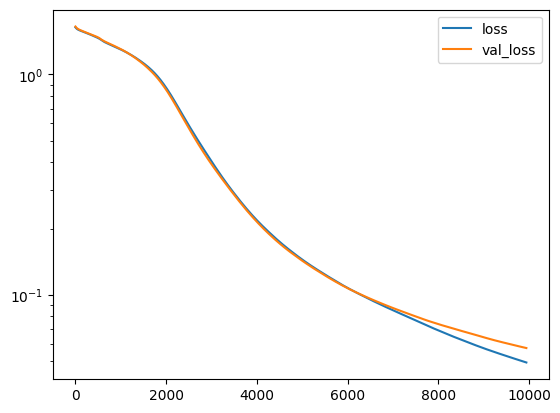

In [11]:
X_test, y_test = X_test_parent, y_test_parent
X_test_norm = scaler.transform(X_test)     

plt.yscale('log')
plt.plot(hist[:, 0], label="loss")
plt.plot(hist[:, 1], label="val_loss")
plt.legend()

In [12]:
predicts = predict_classification(model, X_test_norm, task='multiclass')

metrics = classification_metrics(y_test, predicts, task='multiclass')
print(metrics)

{'accuracy': np.float64(0.983), 'precision': 0.9831901057177156, 'recall': 0.9828604322683301, 'f1': 0.982935179401926}


In [13]:
def plot_classification_results(X_train, X_test, y_train, y_test, y_pred,
                                dim_reducer='pca',
                                title='Classification Results', figsize=(10, 8)):
    """
    Визуализирует обучающую и тестовую выборки с результатами классификации.
    При необходимости уменьшает размерность до 2D с помощью PCA или другого reducer.

    Параметры:
    ----------
    X_train : np.ndarray, shape (n_train, n_features)
        Признаки обучающей выборки.
    X_test : np.ndarray, shape (n_test, n_features)
        Признаки тестовой выборки.
    y_train : np.ndarray, shape (n_train,)
        Истинные метки классов для обучающей выборки.
    y_test : np.ndarray, shape (n_test,)
        Истинные метки классов для тестовой выборки.
    y_pred : np.ndarray, shape (n_test,)
        Предсказанные метки для тестовой выборки.
    dim_reducer : str or object or None
        Способ уменьшения размерности. Возможные значения:
        - None : данные уже 2D (X.shape[1] == 2).
        - 'pca' : использовать PCA (по умолчанию).
        - объект с методами fit_transform и transform (например, обученный PCA).
    title : str
        Заголовок графика.
    figsize : tuple
        Размер фигуры.
    """
    # Приводим метки к плоскому виду
    y_train = np.asarray(y_train).flatten()
    y_test = np.asarray(y_test).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # --- Уменьшение размерности до 2D ---
    if dim_reducer is None:
        # Данные должны быть 2D
        if X_train.shape[1] != 2 or X_test.shape[1] != 2:
            raise ValueError("dim_reducer=None, но входные данные не 2D. Используйте 'pca' или другой редуктор.")
        X_train_2d = X_train
        X_test_2d = X_test
    elif dim_reducer == 'pca':
        # Обучаем PCA только на обучающих данных
        pca = PCA(n_components=2)
        X_train_2d = pca.fit_transform(X_train)
        X_test_2d = pca.transform(X_test)
        print(f"PCA объясняет {pca.explained_variance_ratio_.sum():.2%} дисперсии.")
    elif dim_reducer == 'tsne':
        tsne = TSNE(n_components=2, random_state=seed)
        X_combined = np.vstack([X_train, X_test])
        X_combined_2d = tsne.fit_transform(X_combined)
        X_train_2d = X_combined_2d[:len(X_train)]
        X_test_2d = X_combined_2d[len(X_train):]
        print("t-SNE выполнен.")
    else:
        # Пользовательский reducer (должен иметь методы fit_transform и transform)
        try:
            X_train_2d = dim_reducer.fit_transform(X_train)
            X_test_2d = dim_reducer.transform(X_test)
        except AttributeError:
            raise ValueError("dim_reducer должен быть объектом с методами fit_transform и transform, или 'pca', или None.")

    # --- Далее код как раньше, но с X_train_2d, X_test_2d ---
    unique_classes = np.unique(np.concatenate([y_train, y_test]))
    n_classes = len(unique_classes)
    colormap = plt.cm.get_cmap('tab10', n_classes)
    colors = {cls: colormap(i) for i, cls in enumerate(unique_classes)}

    plt.figure(figsize=figsize)

    # Обучающие точки
    for cls in unique_classes:
        mask = (y_train == cls)
        if np.any(mask):
            plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                        color=colors[cls], marker='o', s=30, alpha=0.7, edgecolors='none',
                        label=f'Train class {cls}')

    correct_mask = (y_pred == y_test)
    incorrect_mask = ~correct_mask

    # Правильно предсказанные
    for cls in unique_classes:
        mask = correct_mask & (y_test == cls)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=colors[cls], marker='o', s=60, alpha=0.8,
                        edgecolors='green', linewidths=1.5,
                        label=f'Correct: class {cls}')

    # Неправильно предсказанные
    for cls in unique_classes:
        mask = incorrect_mask & (y_test == cls)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=colors[cls], marker='x', s=70, alpha=0.9,
                        edgecolors='red', linewidths=1.5,
                        label=f'Incorrect: class {cls}')

    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.title(title)
    plt.xlabel('Component 1' if dim_reducer else 'Feature 1')
    plt.ylabel('Component 2' if dim_reducer else 'Feature 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

t-SNE выполнен.


/tmp/ipykernel_7924/230763182.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab10', n_classes)
/tmp/ipykernel_7924/230763182.py:95: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],


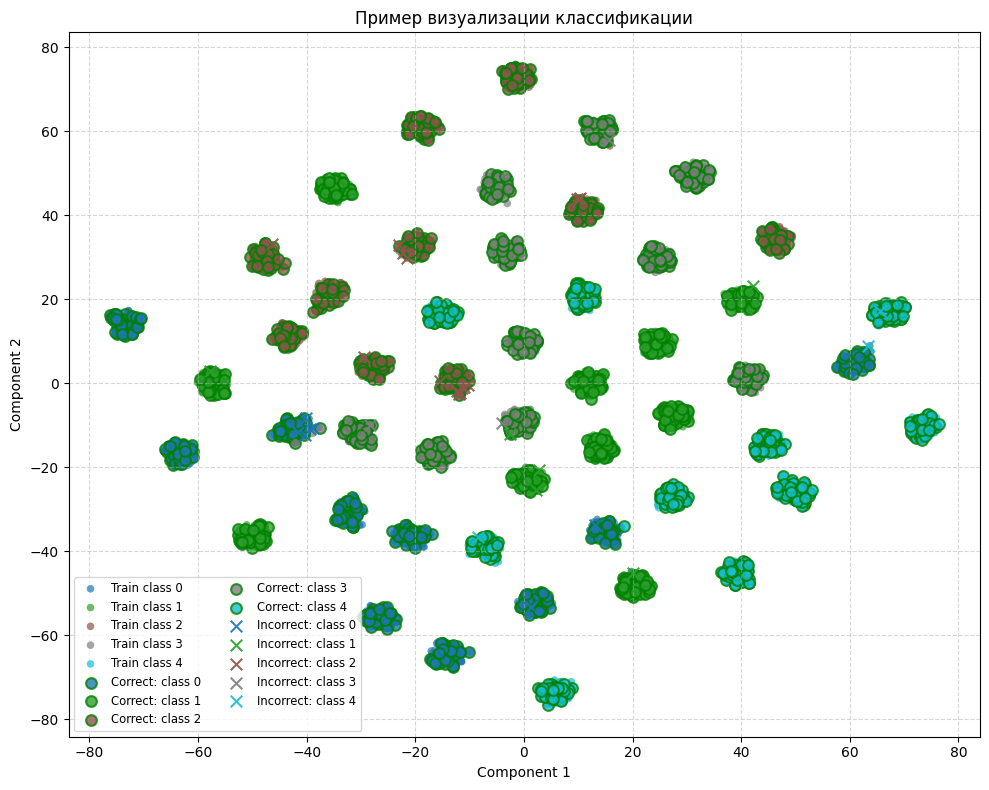

In [14]:
plot_classification_results(X_train_norm, X_test_norm, y_train, y_test, predicts,
                            dim_reducer='tsne',
                            title='Пример визуализации классификации')

In [15]:
def plot_classification_regions(model, X_train, X_test, y_train, y_test, y_pred,
                                task='multiclass', threshold=0.5,
                                resolution=100, padding=0.5,
                                title='Classification Results with Decision Regions',
                                figsize=(10, 8), dim_reducer=None):
    """
    Визуализирует обучающую и тестовую выборки с результатами классификации,
    а также отображает решающие области модели с помощью contourf.
    При необходимости уменьшает размерность до 2D с помощью PCA или другого reducer
    (должен поддерживать inverse_transform для построения сетки).

    Параметры:
    ----------
    model : обученная модель с методом predict (или forward)
    X_train, X_test : массивы признаков (может быть >2)
    y_train, y_test, y_pred : метки классов
    task, threshold : параметры predict_classification
    resolution : разрешение сетки
    padding : отступ вокруг данных
    title, figsize : параметры графика
    dim_reducer : str or object or None
        - None : данные считаются уже 2D
        - 'pca' : использовать PCA (обученный на X_train)
        - объект с методами fit_transform, transform и inverse_transform
    """
    # Приводим метки к плоскому виду
    y_train = np.asarray(y_train).flatten()
    y_test = np.asarray(y_test).flatten()
    y_pred = np.asarray(y_pred).flatten()

    # --- Уменьшение размерности и подготовка 2D данных ---
    if dim_reducer is None:
        if X_train.shape[1] != 2 or X_test.shape[1] != 2:
            raise ValueError("dim_reducer=None, но входные данные не 2D. Используйте 'pca' или другой редуктор.")
        X_train_2d = X_train
        X_test_2d = X_test
        use_inverse = False
    elif dim_reducer == 'pca':
        pca = PCA(n_components=2)
        X_train_2d = pca.fit_transform(X_train)
        X_test_2d = pca.transform(X_test)
        print(f"PCA объясняет {pca.explained_variance_ratio_.sum():.2%} дисперсии.")
        reducer = pca
        use_inverse = True
    elif dim_reducer == 'tsne':
        tsne = TSNE(n_components=2, random_state=42)  # random_state для воспроизводимости
        X_combined = np.vstack([X_train, X_test])
        X_combined_2d = tsne.fit_transform(X_combined)
        X_train_2d = X_combined_2d[:len(X_train)]
        X_test_2d = X_combined_2d[len(X_train):]
        print("t-SNE выполнен.")
        reducer = tsne
        use_inverse = False  # t-SNE не поддерживает обратное преобразование
    else:
        # Пользовательский reducer
        try:
            X_train_2d = dim_reducer.fit_transform(X_train)
            X_test_2d = dim_reducer.transform(X_test)
            reducer = dim_reducer
            use_inverse = hasattr(reducer, 'inverse_transform')
            if not use_inverse:
                print("Внимание: переданный reducer не поддерживает inverse_transform. Контурные области построены не будут.")
        except AttributeError:
            raise ValueError("dim_reducer должен быть объектом с методами fit_transform и transform, или 'pca', или None.")

    # --- Подготовка данных для контурных областей ---
    if use_inverse:
        # Определяем границы в 2D пространстве компонент
        x_min = X_train_2d[:, 0].min() - padding
        x_max = X_train_2d[:, 0].max() + padding
        y_min = X_train_2d[:, 1].min() - padding
        y_max = X_train_2d[:, 1].max() + padding

        xx, yy = np.meshgrid(np.linspace(x_min, x_max, resolution),
                             np.linspace(y_min, y_max, resolution))
        grid_2d = np.c_[xx.ravel(), yy.ravel()]

        # Восстанавливаем исходные координаты (приближённо)
        grid_original = reducer.inverse_transform(grid_2d)

        # Предсказываем классы для всех точек сетки
        grid_pred_original = predict_classification(model, grid_original, task=task, threshold=threshold)
    else:
        # Если reducer не поддерживает inverse_transform, строим только scatter
        grid_pred_original = None
        xx = yy = Z = None

    # --- Построение графика ---
    # Единое отображение классов в индексы
    unique_classes = np.unique(np.concatenate([y_train, y_test]))
    n_classes = len(unique_classes)
    class_to_index = {cls: i for i, cls in enumerate(unique_classes)}
    y_train_idx = np.array([class_to_index[c] for c in y_train])
    y_test_idx = np.array([class_to_index[c] for c in y_test])
    y_pred_idx = np.array([class_to_index[c] for c in y_pred])

    # Цветовая карта
    cmap = plt.cm.get_cmap('tab10', n_classes)
    norm = BoundaryNorm(np.arange(n_classes + 1) - 0.5, n_classes)

    plt.figure(figsize=figsize)

    # Контурные области
    if use_inverse and grid_pred_original is not None:
        grid_pred_idx = np.array([class_to_index[c] for c in grid_pred_original])
        Z = grid_pred_idx.reshape(xx.shape)
        plt.contourf(xx, yy, Z, cmap=cmap, norm=norm, alpha=0.3)

    # Обучающие точки
    for idx, cls in enumerate(unique_classes):
        mask = (y_train_idx == idx)
        if np.any(mask):
            plt.scatter(X_train_2d[mask, 0], X_train_2d[mask, 1],
                        color=cmap(idx), marker='o', s=30, alpha=0.7, edgecolors='none',
                        label=f'Train class {cls}')

    # Тестовые точки: правильно и неправильно предсказанные
    correct = (y_pred_idx == y_test_idx)
    incorrect = ~correct

    for idx, cls in enumerate(unique_classes):
        # Правильно предсказанные
        mask = correct & (y_test_idx == idx)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=cmap(idx), marker='o', s=60, alpha=0.8,
                        edgecolors='green', linewidths=1.5,
                        label=f'Correct: class {cls}')
        # Неправильно предсказанные
        mask = incorrect & (y_test_idx == idx)
        if np.any(mask):
            plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],
                        color=cmap(idx), marker='x', s=70, alpha=0.9,
                        edgecolors='red', linewidths=1.5,
                        label=f'Incorrect: class {cls}')

    plt.legend(loc='best', fontsize='small', ncol=2)
    plt.title(title)
    if dim_reducer is None:
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
    else:
        plt.xlabel('Component 1')
        plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

t-SNE выполнен.


/tmp/ipykernel_7924/1511045181.py:98: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_classes)
/tmp/ipykernel_7924/1511045181.py:132: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_test_2d[mask, 0], X_test_2d[mask, 1],


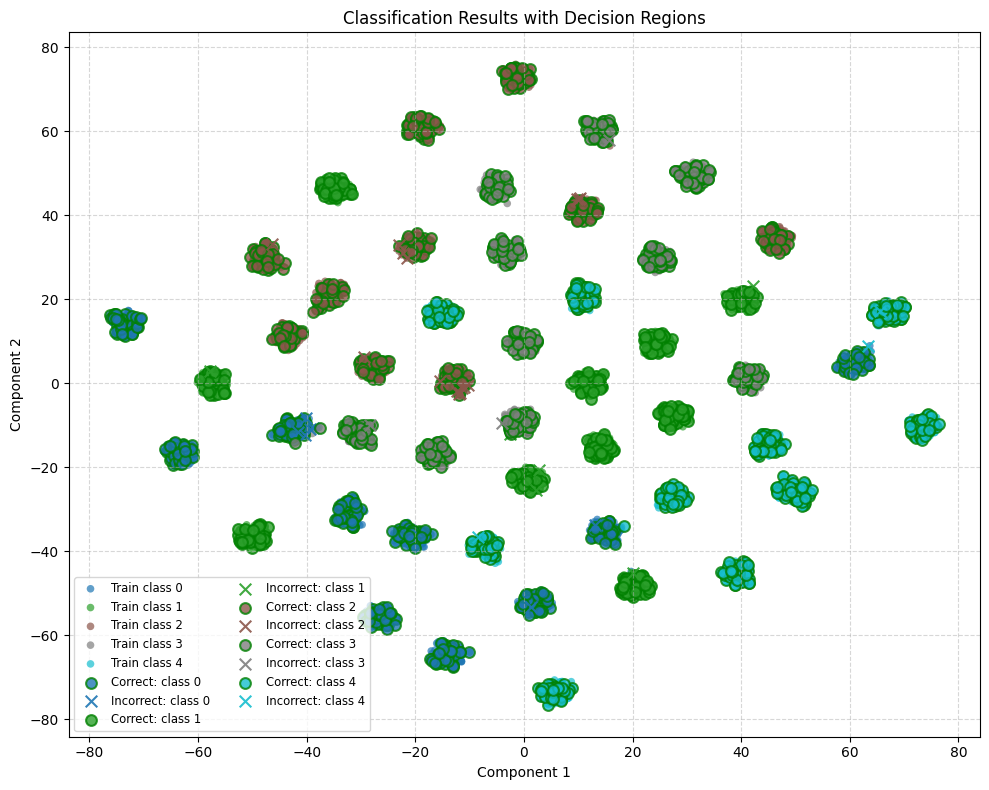

In [16]:

plot_classification_regions(model, X_train_norm, X_test_norm, y_train, y_test, predicts,
                            dim_reducer='tsne')